In [1]:
# IMDB 리뷰 데이터 셋
from tensorflow.keras.datasets import imdb

(train_input, train_target), (test_input, test_target) \
                = imdb.load_data(num_words=500)

In [2]:
print(train_input.shape, test_input.shape)

(25000,) (25000,)


In [3]:
# 훈련 세트에서 1(문장의 시작), 2(어휘 사전에 없는 단어) 제외하기

for i in range(len(train_input)):
    train_input[i] = [w for w in train_input[i] if w > 2]
    
print(print(train_input[0]))

[14, 22, 16, 43, 65, 458, 66, 4, 173, 36, 256, 5, 25, 100, 43, 112, 50, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 336, 385, 39, 4, 172, 17, 38, 13, 447, 4, 192, 50, 16, 6, 147, 19, 14, 22, 4, 469, 4, 22, 71, 87, 12, 16, 43, 38, 76, 15, 13, 4, 22, 17, 17, 12, 16, 18, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 16, 480, 66, 33, 4, 130, 12, 16, 38, 5, 25, 124, 51, 36, 135, 48, 25, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 8, 4, 107, 117, 15, 256, 4, 7, 5, 36, 71, 43, 476, 26, 400, 317, 46, 7, 4, 13, 104, 88, 4, 381, 15, 297, 98, 32, 56, 26, 141, 6, 194, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 88, 12, 16, 283, 5, 16, 113, 103, 32, 15, 16, 19, 178, 32]
None


In [4]:
from sklearn.model_selection import train_test_split

train_input, val_input, train_target, val_target = \
    train_test_split(train_input, train_target, test_size=0.2,
                     random_state=42)

In [5]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 시퀸스 데이터의 길이를 맞춰 줌.
train_seq = pad_sequences(train_input, maxlen=100, padding='pre')
train_seq.shape

(20000, 100)

In [6]:
val_seq = pad_sequences(val_input, maxlen=100)

## 순환 신경망 만들기

In [ ]:
# keras.layers.LSTM() 모델 적용, SimpleRNN() 보다 개선되어진 모델
# model.add(keras.layers.SimpleRNN(8)) 과 비교
from tensorflow import keras

model = keras.Sequential()

model.add(keras.Input(shape=(100,)))
model.add(keras.layers.Embedding(500, 16))
model.add(keras.layers.LSTM(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ModelCheckpoint() 최적의 알고리즘을 찾으면 저장(완성된 모델)
# EarlyStopping() 손실이 더 적어지거나 더 커지지 않도록 조기 종료

model.compile(loss='binary_crossentropy',
              optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              metrics=['accuracy'])

check_cb = keras.callbacks.ModelCheckpoint('best_LSTM_model.h5', save_best_only=True)
early_stopping = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(train_seq, train_target, epochs=100, batch_size=64,
                   validation_data=(val_seq, val_target),
                   callbacks=[check_cb, early_stopping])

Epoch 1/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5998 - loss: 0.6910

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5998 - loss: 0.6910 - val_accuracy: 0.6714 - val_loss: 0.6862
Epoch 2/100
308/313 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6994 - loss: 0.6286

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7003 - loss: 0.6277 - val_accuracy: 0.7446 - val_loss: 0.5731
Epoch 3/100
310/313 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7575 - loss: 0.5560

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7577 - loss: 0.5559 - val_accuracy: 0.7664 - val_loss: 0.5419
Epoch 4/100
309/313 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7780 - loss: 0.5237

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7778 - loss: 0.5236 - val_accuracy: 0.7740 - val_loss: 0.5174
Epoch 5/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7900 - loss: 0.4984

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8231 - loss: 0.4059 - val_accuracy: 0.8100 - val_loss: 0.4283
Epoch 15/100
308/313 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8252 - loss: 0.4029

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8256 - loss: 0.4025 - val_accuracy: 0.8102 - val_loss: 0.4269
Epoch 16/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8253 - loss: 0.3994

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8253 - loss: 0.3994 - val_accuracy: 0.8102 - val_loss: 0.4239
Epoch 17/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8270 - loss: 0.3974 - val_accuracy: 0.8076 - val_loss: 0.4242
Epoch 18/100
310/313 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8285 - loss: 0.3949

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8281 - loss: 0.3951 - val_accuracy: 0.8102 - val_loss: 0.4226
Epoch 19/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8284 - loss: 0.3933 - val_accuracy: 0.8106 - val_loss: 0.4228
Epoch 20/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8306 - loss: 0.3918

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8306 - loss: 0.3919 - val_accuracy: 0.8106 - val_loss: 0.4189
Epoch 21/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8303 - loss: 0.3896 - val_accuracy: 0.8096 - val_loss: 0.4210
Epoch 22/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8293 - loss: 0.3886 - val_accuracy: 0.8102 - val_loss: 0.4200
Epoch 23/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8306 - loss: 0.3871 - val_accuracy: 0.8102 - val_loss: 0.4229


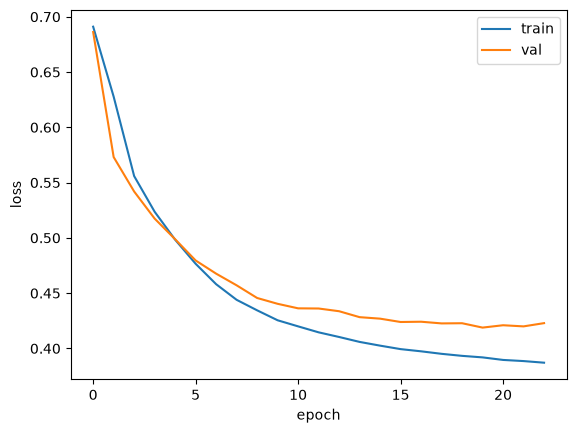

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch') # 반복횟수
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()